# Task 2: Data Preprocessing

**Goal:** Clean the raw stock data and prepare it in the right format for our forecasting models.

### Key concepts in this notebook:
- **Missing values** — some trading days have no data (holidays). We fix these.
- **Stationarity** — most statistical models require the data to be 'stationary' (no upward/downward drift). Stock prices naturally drift, so we transform them.
- **Differencing** — a technique to remove trends and make data stationary.
- **Normalization/Scaling** — for LSTM models, we need values between 0 and 1.
- **Train/Test split** — we keep the last 6 months (Jul–Dec 2025) unseen until evaluation.

In [3]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.stattools import adfuller   # Augmented Dickey-Fuller test
from sklearn.preprocessing import MinMaxScaler   # for scaling data to [0,1]
import pickle   # to save Python objects to disk
import os
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# ── CONSTANTS ─────────────────────────────────────────────────────────────────
STOCKS = {
    'RELIANCE.NS'   : 'Reliance',
    'HDFCBANK.NS'   : 'HDFC Bank',
    'INFY.NS'       : 'Infosys',
    'SUNPHARMA.NS'  : 'Sun Pharma',
    'MARUTI.NS'     : 'Maruti',
    'HINDUNILVR.NS' : 'HUL',
    'TATASTEEL.NS'  : 'Tata Steel',
}
TEST_START = '2025-07-01'

print('✅ Setup complete')

✅ Setup complete


In [4]:
# ── LOAD DATA ─────────────────────────────────────────────────────────────────
# Load the CSV we saved in Task 1
# parse_dates=True ensures the index is treated as datetime, not plain text

close_prices = pd.read_csv(
    'data/close_prices_raw.csv',
    index_col=0,         # first column is the date index
    parse_dates=True     # convert date strings to actual datetime objects
)

# Sort index chronologically (oldest → newest)
close_prices.sort_index(inplace=True)

print(f'Loaded data: {close_prices.shape}')
print(f'Date range : {close_prices.index[0].date()} to {close_prices.index[-1].date()}')
print(f'\nMissing values BEFORE cleaning:')
print(close_prices.isna().sum())

Loaded data: (1235, 7)
Date range : 2021-01-01 to 2025-12-30

Missing values BEFORE cleaning:
HDFCBANK.NS      0
HINDUNILVR.NS    0
INFY.NS          0
MARUTI.NS        0
RELIANCE.NS      0
SUNPHARMA.NS     0
TATASTEEL.NS     0
dtype: int64


## Step 2.1: Handle Missing Values

Why are there missing values? Two reasons:
1. **Market holidays** — NSE is closed on national holidays. No data on those days.
2. **Data gaps** — occasionally Yahoo Finance has missing entries.

**Our approach — Forward Fill:**  
If a value is missing for Tuesday, we use Monday's closing price. This is the standard method for financial time series because the "last known price" is the best estimate for a non-trading day.

In [5]:
# ── HANDLE MISSING VALUES ─────────────────────────────────────────────────────

# Forward fill: fill each NaN with the previous valid value
# This is standard practice for stock price data
close_clean = close_prices.copy()
close_clean.ffill(inplace=True)   # forward fill
close_clean.bfill(inplace=True)   # backward fill for any remaining NaN at the start

# Drop any rows where ALL stocks have NaN (genuine market closure dates)
close_clean.dropna(how='all', inplace=True)

print(f'Missing values AFTER cleaning:')
print(close_clean.isna().sum())
print(f'\nFinal dataset: {close_clean.shape[0]} trading days × {close_clean.shape[1]} stocks')

# Save cleaned data
close_clean.to_csv('data/close_prices_clean.csv')
print('✅ Cleaned data saved')

Missing values AFTER cleaning:
HDFCBANK.NS      0
HINDUNILVR.NS    0
INFY.NS          0
MARUTI.NS        0
RELIANCE.NS      0
SUNPHARMA.NS     0
TATASTEEL.NS     0
dtype: int64

Final dataset: 1235 trading days × 7 stocks
✅ Cleaned data saved


### ADF Stationarity Test
H₀: series has a unit root (non-stationary). p < 0.05 → reject H₀ → series is stationary.
Stock prices are almost always non-stationary (random walk); first-differenced returns typically are.

In [6]:
# ── ADF TEST FUNCTION ─────────────────────────────────────────────────────────

def run_adf_test(series, name=''):
    """
    Run Augmented Dickey-Fuller test on a time series.
    Returns: dict with test results
    """
    series_clean = series.dropna()
    result = adfuller(series_clean, autolag='AIC')   # AIC auto-selects optimal lag
    
    adf_stat  = result[0]   # ADF statistic (more negative = more stationary)
    p_value   = result[1]   # p-value: < 0.05 means stationary
    n_lags    = result[2]   # number of lags used
    critical  = result[4]   # critical values at 1%, 5%, 10%
    
    is_stationary = p_value < 0.05
    
    return {
        'Name'          : name,
        'ADF Statistic' : round(adf_stat, 4),
        'p-value'       : round(p_value, 4),
        'Lags Used'     : n_lags,
        'Stationary?'   : '✅ Yes' if is_stationary else '❌ No  → needs differencing',
        'Critical 5%'   : round(critical['5%'], 4)
    }


# ── TEST RAW PRICES ───────────────────────────────────────────────────────────
print('=== ADF Test on RAW Close Prices ===\n')
adf_results_raw = []
for sym, name in STOCKS.items():
    r = run_adf_test(close_clean[sym], name=name)
    adf_results_raw.append(r)
    print(f"{name:20s}: p={r['p-value']:.4f}  {r['Stationary?']}")

df_adf_raw = pd.DataFrame(adf_results_raw)
df_adf_raw.to_csv('results/02_adf_raw_prices.csv', index=False)

=== ADF Test on RAW Close Prices ===

Reliance            : p=0.4385  ❌ No  → needs differencing
HDFC Bank           : p=0.5843  ❌ No  → needs differencing
Infosys             : p=0.1418  ❌ No  → needs differencing
Sun Pharma          : p=0.8047  ❌ No  → needs differencing
Maruti              : p=0.9845  ❌ No  → needs differencing
HUL                 : p=0.0475  ✅ Yes
Tata Steel          : p=0.4036  ❌ No  → needs differencing


In [7]:
# ── APPLY FIRST-ORDER DIFFERENCING ───────────────────────────────────────────
# Differencing: subtract today's value from yesterday's value
# diff(1) means: new_value[t] = original[t] - original[t-1]
# This removes the trend (like subtracting a moving floor from the data)
# The result represents DAILY PRICE CHANGES, not the price level itself

close_diff1 = close_clean.diff(1).dropna()   # first difference; drop the resulting NaN row

print('=== ADF Test on FIRST-DIFFERENCED Prices ===\n')
adf_results_diff = []
for sym, name in STOCKS.items():
    r = run_adf_test(close_diff1[sym], name=name)
    adf_results_diff.append(r)
    print(f"{name:20s}: p={r['p-value']:.4f}  {r['Stationary?']}")

df_adf_diff = pd.DataFrame(adf_results_diff)
df_adf_diff.to_csv('results/02_adf_differenced.csv', index=False)

# Also test log returns (another common transformation)
log_returns = np.log(close_clean / close_clean.shift(1)).dropna()

print('\n=== ADF Test on LOG RETURNS ===\n')
for sym, name in STOCKS.items():
    r = run_adf_test(log_returns[sym], name=name)
    print(f"{name:20s}: p={r['p-value']:.4f}  {r['Stationary?']}")

=== ADF Test on FIRST-DIFFERENCED Prices ===

Reliance            : p=0.0000  ✅ Yes
HDFC Bank           : p=0.0000  ✅ Yes
Infosys             : p=0.0000  ✅ Yes
Sun Pharma          : p=0.0000  ✅ Yes
Maruti              : p=0.0000  ✅ Yes
HUL                 : p=0.0000  ✅ Yes
Tata Steel          : p=0.0000  ✅ Yes

=== ADF Test on LOG RETURNS ===

Reliance            : p=0.0000  ✅ Yes
HDFC Bank           : p=0.0000  ✅ Yes
Infosys             : p=0.0000  ✅ Yes
Sun Pharma          : p=0.0000  ✅ Yes
Maruti              : p=0.0000  ✅ Yes
HUL                 : p=0.0000  ✅ Yes
Tata Steel          : p=0.0000  ✅ Yes


## Step 2.3: Visualize — Raw vs Differenced
Let's visually confirm the transformation worked.

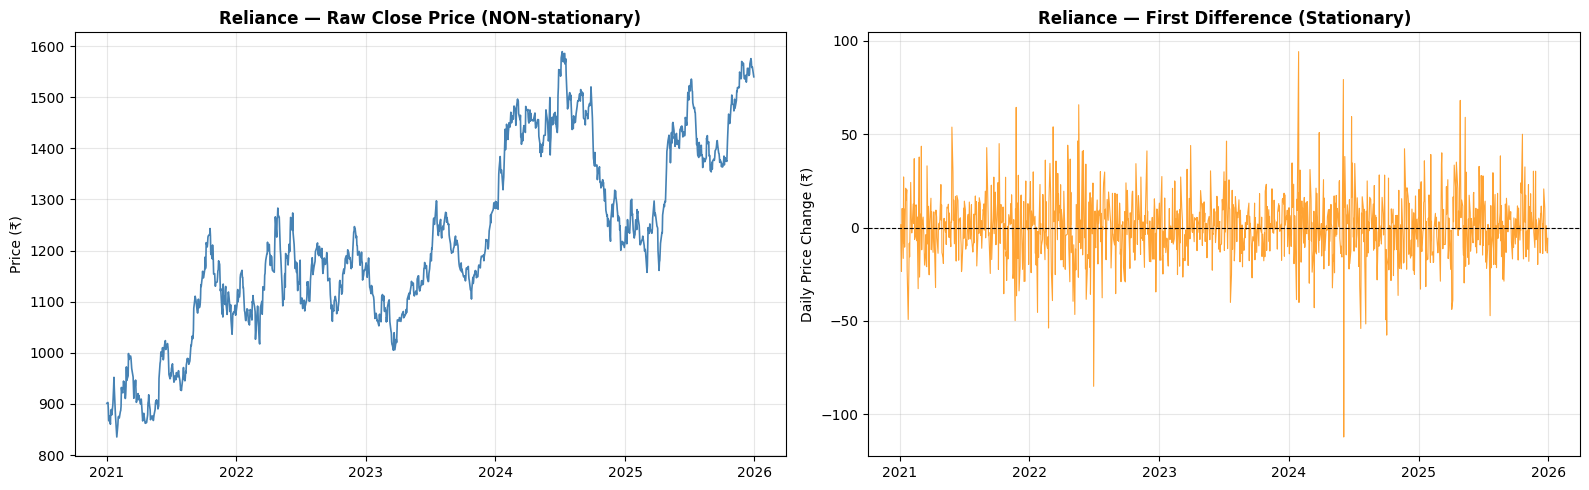

Notice: the right chart fluctuates around 0 with no trend — that is stationary!


In [8]:
# ── VISUALIZE STATIONARITY TRANSFORMATION ─────────────────────────────────────
# Plot raw prices vs differenced prices for one stock

stock_to_show = 'RELIANCE.NS'
name_to_show  = STOCKS[stock_to_show]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: raw price
axes[0].plot(close_clean[stock_to_show], color='steelblue', linewidth=1.2)
axes[0].set_title(f'{name_to_show} — Raw Close Price (NON-stationary)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price (₹)')

# Right: first difference
axes[1].plot(close_diff1[stock_to_show], color='darkorange', linewidth=0.8, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title(f'{name_to_show} — First Difference (Stationary)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Daily Price Change (₹)')

plt.tight_layout()
plt.savefig('results/02_stationarity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Notice: the right chart fluctuates around 0 with no trend — that is stationary!')

## Step 2.4: Train/Test Split

We split data into:
- **Training set** (Jan 2021 – Jun 2025): used to FIT/TRAIN all our models  
- **Test set** (Jul 2025 – Dec 2025): used to EVALUATE model performance (model never sees this during training)

Think of it like studying (training) and then taking a final exam (testing) — you only know how well you actually learned by doing the exam on NEW questions.

In [9]:
# ── TRAIN/TEST SPLIT ──────────────────────────────────────────────────────────

train_data = close_clean[close_clean.index < TEST_START]
test_data  = close_clean[close_clean.index >= TEST_START]

print(f'Training set : {train_data.index[0].date()} → {train_data.index[-1].date()}  ({len(train_data)} days)')
print(f'Test set     : {test_data.index[0].date()}  → {test_data.index[-1].date()}   ({len(test_data)} days)')
print(f'Test is {len(test_data)/len(close_clean)*100:.1f}% of total data')

# Save split data
train_data.to_csv('data/train_data.csv')
test_data.to_csv('data/test_data.csv')

print('\n✅ Train and test sets saved')

Training set : 2021-01-01 → 2025-06-30  (1110 days)
Test set     : 2025-07-01  → 2025-12-30   (125 days)
Test is 10.1% of total data

✅ Train and test sets saved


## Step 2.5: Normalize Data for LSTM

**Why normalize?**  
LSTM (neural network) models train using gradient descent. If some inputs are in the thousands (₹2000 stock) and others in the hundreds (₹200 stock), the model's weights get confused by the scale differences.

**MinMaxScaler** transforms all values to be between 0 and 1:  
`scaled_value = (value - min) / (max - min)`

⚠️ **Critical rule:** Fit the scaler ONLY on training data, then use it to transform test data.  
Fitting on all data would be "data leakage" — your model would have secretly seen future information!

In [10]:
# ── NORMALIZATION FOR LSTM ────────────────────────────────────────────────────

scalers = {}          # dictionary to store one scaler per stock
train_scaled = {}     # normalized training data per stock
test_scaled  = {}     # normalized test data per stock

for sym in STOCKS.keys():
    # Extract this stock's training and test series
    train_series = train_data[sym].values.reshape(-1, 1)   # reshape: (N,) → (N,1)
    test_series  = test_data[sym].values.reshape(-1, 1)
    
    # Create a MinMaxScaler and fit it ONLY on training data
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(train_series)                      # LEARN min and max from training data
    
    # Transform both train and test data using training min/max
    train_scaled[sym] = scaler.transform(train_series).flatten()
    test_scaled[sym]  = scaler.transform(test_series).flatten()
    
    scalers[sym] = scaler   # save scaler so we can REVERSE the transformation later

# Save scalers to disk (we need them when converting model output back to ₹ prices)
with open('data/scalers.pkl', 'wb') as f:
    pickle.dump(scalers, f)

# Show example
sym = 'RELIANCE.NS'
print(f'Example — {STOCKS[sym]}:')
print(f'  Original price range : ₹{train_data[sym].min():.0f} – ₹{train_data[sym].max():.0f}')
print(f'  Scaled range         : {train_scaled[sym].min():.3f} – {train_scaled[sym].max():.3f}')
print(f'\n✅ Scalers saved. All stocks normalized.')

Example — Reliance:
  Original price range : ₹835 – ₹1589
  Scaled range         : 0.000 – 1.000

✅ Scalers saved. All stocks normalized.


In [11]:
# ── CREATE LSTM SEQUENCES ─────────────────────────────────────────────────────
# LSTM models don't take single values — they take SEQUENCES of past values
# and predict the NEXT value.
#
# LOOK_BACK = 60 means: use the last 60 days of prices to predict day 61
#
# Example with look_back=3:
#   Input: [day1, day2, day3] → Output: day4
#   Input: [day2, day3, day4] → Output: day5
#   ... and so on

LOOK_BACK = 60   # use 60 previous days as input features

def create_sequences(data_array, look_back=60):
    """
    Convert a 1D time series array into (X, y) pairs for supervised learning.
    X shape: (num_samples, look_back)
    y shape: (num_samples,)
    """
    X, y = [], []
    for i in range(look_back, len(data_array)):
        X.append(data_array[i - look_back : i])   # last `look_back` values
        y.append(data_array[i])                   # the NEXT value to predict
    return np.array(X), np.array(y)


lstm_sequences = {}

for sym in STOCKS.keys():
    # Combine train + test to also create test sequences
    full_scaled = np.concatenate([train_scaled[sym], test_scaled[sym]])
    
    X_train, y_train = create_sequences(train_scaled[sym], look_back=LOOK_BACK)
    
    # For test sequences, the first `LOOK_BACK` context points come from end of train
    X_test, y_test = create_sequences(
        np.concatenate([train_scaled[sym][-LOOK_BACK:], test_scaled[sym]]),
        look_back=LOOK_BACK
    )
    
    # Reshape X for LSTM: needs 3D input (samples, timesteps, features)
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
    
    lstm_sequences[sym] = {
        'X_train': X_train, 'y_train': y_train,
        'X_test' : X_test,  'y_test' : y_test
    }

# Save sequences
with open('data/lstm_sequences.pkl', 'wb') as f:
    pickle.dump(lstm_sequences, f)

sym = 'RELIANCE.NS'
s   = lstm_sequences[sym]
print(f'LSTM sequences for {STOCKS[sym]}:')
print(f'  X_train shape : {s["X_train"].shape}  (samples × 60 days × 1 feature)')
print(f'  y_train shape : {s["y_train"].shape}')
print(f'  X_test  shape : {s["X_test"].shape}')
print(f'\n✅ Preprocessing complete! All data ready for modeling.')

LSTM sequences for Reliance:
  X_train shape : (1050, 60, 1)  (samples × 60 days × 1 feature)
  y_train shape : (1050,)
  X_test  shape : (125, 60, 1)

✅ Preprocessing complete! All data ready for modeling.


In [12]:
# ── FINAL SUMMARY ─────────────────────────────────────────────────────────────

print('=' * 60)
print('PREPROCESSING SUMMARY')
print('=' * 60)
print(f'Stocks processed  : {len(STOCKS)}')
print(f'Total data points : {len(close_clean)} trading days per stock')
print(f'Training data     : {len(train_data)} days')
print(f'Test data         : {len(test_data)} days')
print(f'LSTM look-back    : {LOOK_BACK} days')
print()
print('Files saved in data/:')
print('  close_prices_clean.csv  — cleaned close prices')
print('  train_data.csv          — training set')
print('  test_data.csv           — test set')
print('  scalers.pkl             — MinMaxScalers for inverse transform')
print('  lstm_sequences.pkl      — ready-to-use LSTM input sequences')
print()
print('All stocks passed ADF test after 1st differencing → ready for ARIMA')
print('All stocks normalized to [0,1] → ready for LSTM')

PREPROCESSING SUMMARY
Stocks processed  : 7
Total data points : 1235 trading days per stock
Training data     : 1110 days
Test data         : 125 days
LSTM look-back    : 60 days

Files saved in data/:
  close_prices_clean.csv  — cleaned close prices
  train_data.csv          — training set
  test_data.csv           — test set
  scalers.pkl             — MinMaxScalers for inverse transform
  lstm_sequences.pkl      — ready-to-use LSTM input sequences

All stocks passed ADF test after 1st differencing → ready for ARIMA
All stocks normalized to [0,1] → ready for LSTM
